# Computer Vision Final Project - Eye Disease Classification using Retinal Images

## Project Members

- Criswincent Enrico Geraldy — 2802425474
- Gibran Alief Irawan — 2802397325
- Muhammad Nizwa — 2802401833
- Jason Alvaro Gouw — 2802401770
- Lintang Anggowoyuono — 2802398763
- Kent Natan Herlambang — 2802397464

In [3]:
import os
import time
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
sns.set_palette("deep")

import cv2
import scipy
import skimage

from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.filters import gabor

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, f1_score, roc_curve, auc
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

In [4]:
import streamlit as st

print("opencv: ", cv2.__version__)
print("scipy: ", scipy.__version__)
print("skimage: ", skimage.__version__)
print("numpy: ", np.__version__)
print("streamlit: ", st.__version__)

opencv:  4.12.0
scipy:  1.16.3
skimage:  0.26.0
numpy:  2.2.6
streamlit:  1.57.0


## Dataset Preview

Dataset Source: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification

In [2]:
img_path = "./eye_disease_dataset/cataract/_33_692344.jpg"

original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

original_img.shape, original_img.dtype

((256, 256, 3), dtype('uint8'))

Lets take a sample of the images, and see if its a good idea to perform pixel resize.

More pixel = more data processed by the feature extractor

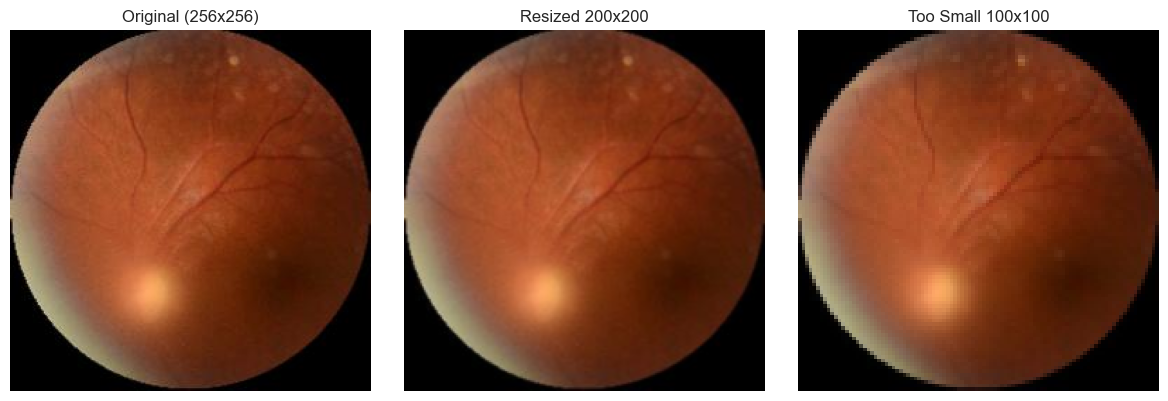

In [3]:
resized_img = cv2.resize(original_img, (200, 200), interpolation=cv2.INTER_AREA)
too_small_img = cv2.resize(original_img, (100, 100), interpolation=cv2.INTER_AREA)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title(f"Original ({original_img.shape[1]}x{original_img.shape[0]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(resized_img)
plt.title(f"Resized 200x200")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(too_small_img)
plt.title("Too Small 100x100")
plt.axis("off")

plt.tight_layout()
plt.show()

## Data preparation: Loading from disk

The following function takes 3 arguments:

- dataset directory path
- the class directory list (already seperated by dir from the original source)
- image size to load

The class label are manually assigned in here.

At the end we shuffle X and y pairs because when we append the data, the class are appended in order, and we don't want this.

In [4]:
def load_data(dataset_path, dir_list, image_size):
    # load all images in a directory
    X = []
    y = []
    image_width, image_height = image_size

    for directory in dir_list:
        dir_path = os.path.join(dataset_path, directory)
        for filename in os.listdir(dir_path):
            # get every img file in the dir path
            path = os.path.join(dir_path, filename)
            # since this is an xray images
            # its better to load the image in grayscale
            # having it only on 1 channel makes computation efficient
            image = cv2.imread(path)
            image =  cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # resize image
            image = cv2.resize(
                image, dsize=(image_width, image_height), interpolation=cv2.INTER_CUBIC
            )
            # append
            X.append(image)
            # assign class labels
            if directory == "normal":
                y.append([0])
            elif directory == "cataract":
                y.append([1])
            elif directory == "diabetic_retinopathy":
                y.append([2])
            elif directory == "glaucoma":
                y.append([3])
            else:
                raise ValueError("no class for:", directory)

    X = np.array(X)
    y = np.array(y)

    # Shuffle the data
    X, y = shuffle(X, y)

    print(f"Number of image sample: {len(X)}")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")

    return X, y

In [69]:
class_mapping = {
    0: "Normal",
    1: "Cataract",
    2: "Diabetic Retinopathy",
    3: "Glaucoma"
}

In [70]:
def class_id_to_name(class_id_list):
    return [class_mapping.get(class_id, "Unknown") for class_id in class_id_list]

We just round up the size from 256x256 to 260x260 and load the images in RGB format, meaning we will end up with 3 color channels

In [5]:
IMG_WIDTH, IMG_HEIGHT = (260, 260)

X, y = load_data("./eye_disease_dataset", ["cataract", "diabetic_retinopathy", "glaucoma", "normal"], (IMG_WIDTH, IMG_HEIGHT))

Number of image sample: 4217
X shape: (4217, 260, 260, 3)
y shape: (4217, 1)


## Compute Class Percentage & Value Count Plots

Calculate the class distribution in percentage, checks for class imbalance

In [6]:
def class_percentage(y):
    y = np.array(y).flatten()

    class_names = {0: "normal", 1: "cataract", 2: "diabetic_retinopathy", 3: "glaucoma"}

    sample_size = len(y)
    print(f"Total samples: {sample_size}\n")

    unique, counts = np.unique(y, return_counts=True)

    for cls, count in zip(unique, counts):
        percentage = (count * 100.0) / sample_size
        name = class_names.get(cls, f"Class {cls}")
        print(f"{name}: {percentage:.2f}%  ({count} samples)")

In [7]:
class_percentage(y)

Total samples: 4217

normal: 25.47%  (1074 samples)
cataract: 24.61%  (1038 samples)
diabetic_retinopathy: 26.04%  (1098 samples)
glaucoma: 23.88%  (1007 samples)


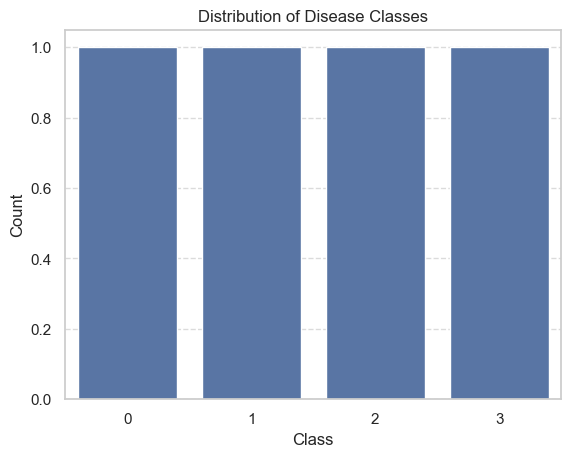

In [8]:
sns.barplot(x=y.flatten(), y=np.ones_like(y.flatten()))
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Distribution of Disease Classes")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [9]:
def plot_sample_images(X, y, n=20):
    y = y.flatten()

    class_names = {0: "normal", 1: "cataract", 2: "diabetic_retinopathy", 3: "glaucoma"}

    for label in class_names.keys():
        idx = np.where(y == label)[0]

        images = X[idx][:n]

        columns_n = 10
        rows_n = int(np.ceil(len(images) / columns_n))

        plt.figure(figsize=(20, 2 * rows_n))

        for i, image in enumerate(images, 1):
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(image.squeeze(), cmap="gray")
            plt.axis("off")

        plt.suptitle(f"Eye: {class_names[label]}")
        plt.show()

## Plot Sample Images 

Lets plot the images, this way we can see every randomized sample from each class

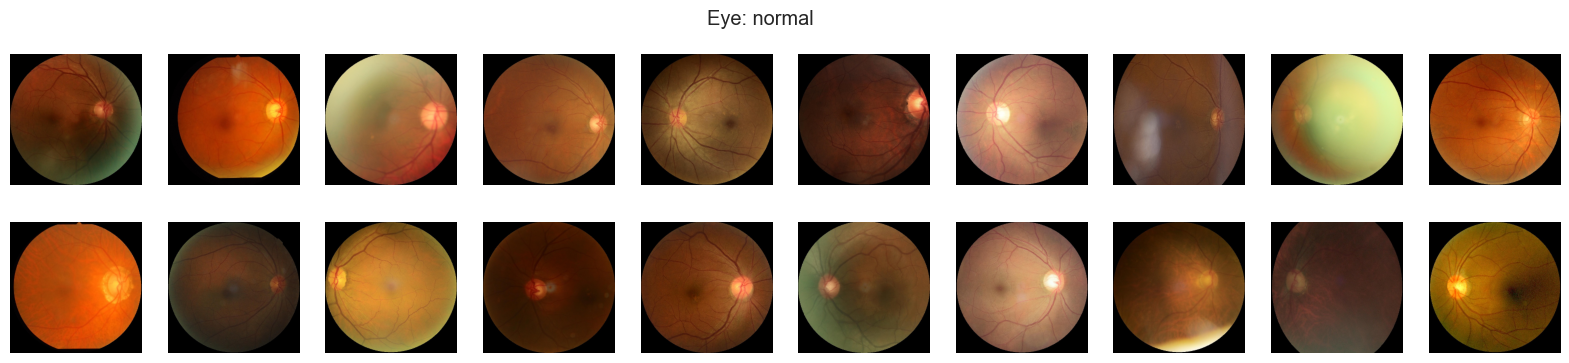

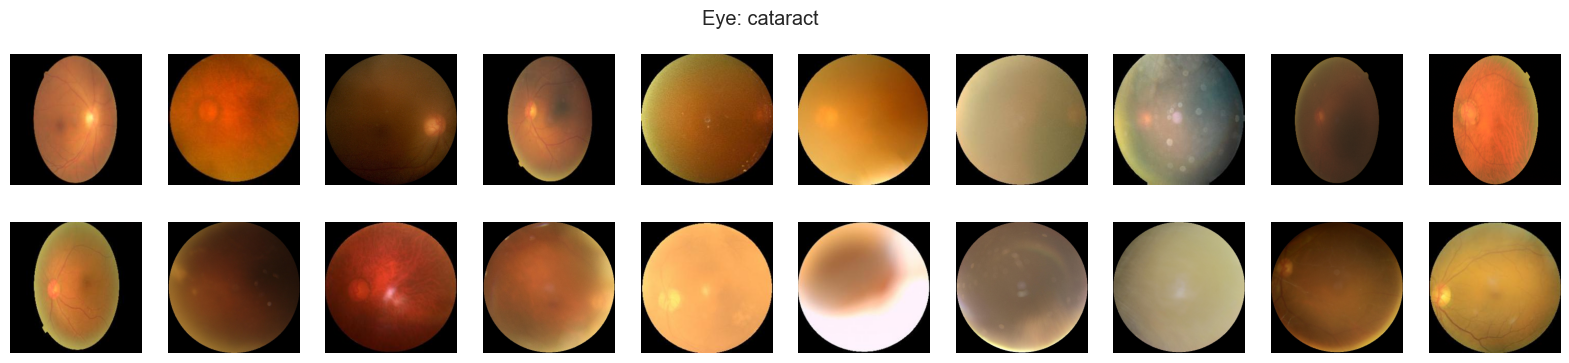

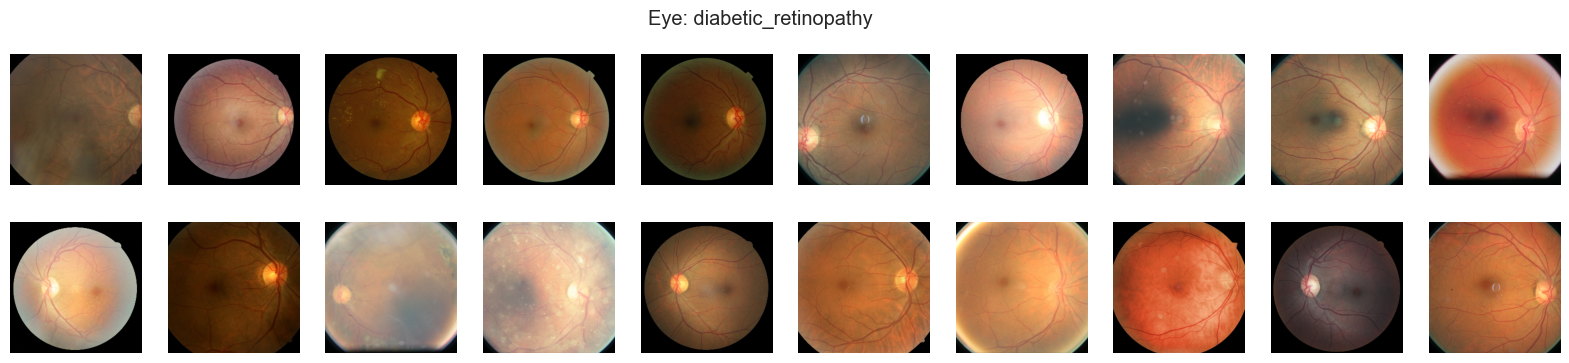

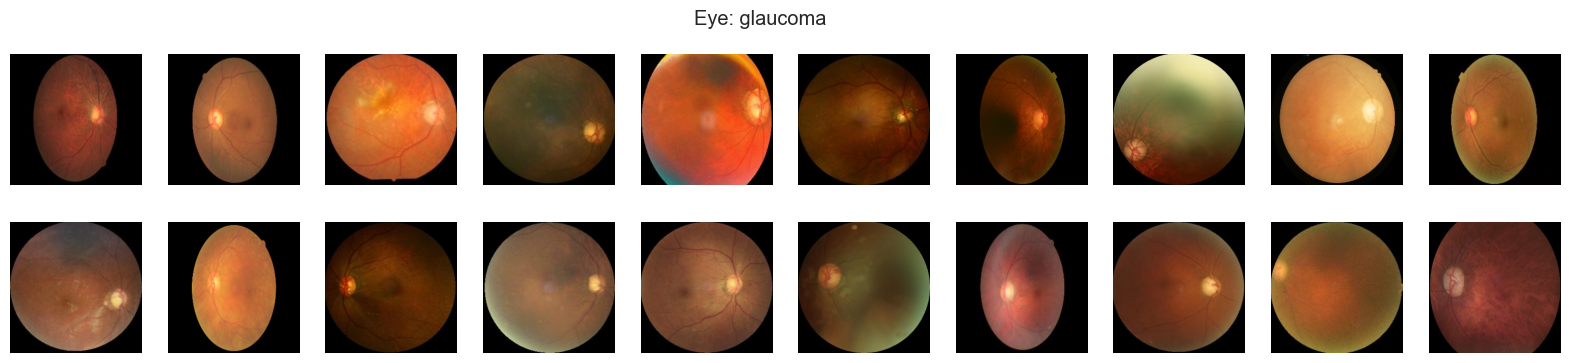

In [10]:
plot_sample_images(X, y)

## Data Preprocessing: CLAHE

The early preprocessing step we take is to apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to every RGB images, enchancing the image contrast that helps dark/low contrast images visually

In [11]:
def apply_clahe(image_rgb, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    per channel on an RGB image.
    """
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    channels = cv2.split(image_rgb)
    enhanced = [clahe.apply(ch) for ch in channels]
    return cv2.merge(enhanced)


def preprocess_dataset(X_raw):
    """Preprocess RGB images dataset using CLAHE."""
    time_start = time.time()
    features = []
    N = len(X_raw)
    for i, img in enumerate(X_raw):
        # logging
        if (i + 1) % 500 == 0 or (i + 1) == N:
            print(f"{i+1}/{N}")
        # extract features
        features.append(apply_clahe(img))
        
    time_end = time.time() - time_start
    print(f"Preprocessed {N} images in {time_end:.2f} seconds")
    return np.array(features, dtype=np.uint8)

Here are the before vs after when applying CLAHE to RGB images

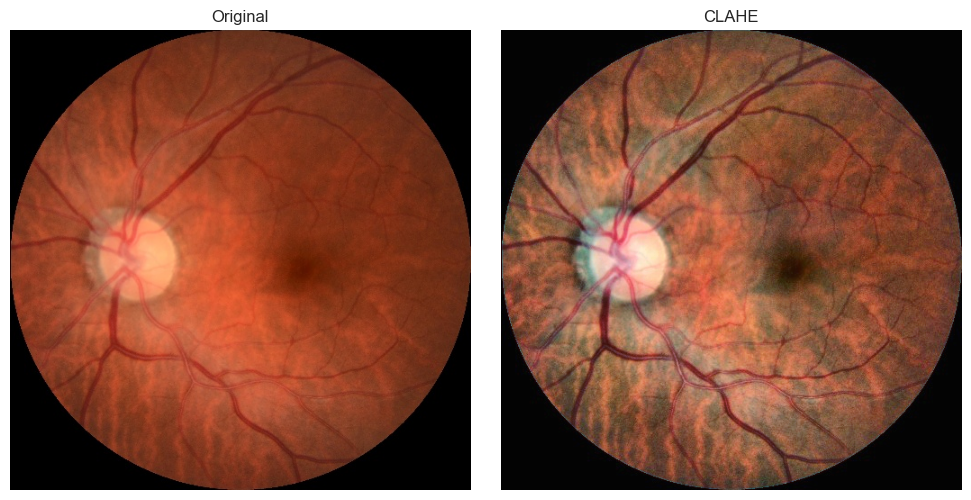

In [12]:
image_path = "./eye_disease_dataset/normal/8_left.jpg"

img_rgb   = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
img_clahe = apply_clahe(img_rgb)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb);   axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(img_clahe); axes[1].set_title("CLAHE");    axes[1].axis("off")
plt.tight_layout()
plt.show()

In [13]:
X_prep = preprocess_dataset(X) # preprocess all images

500/4217
1000/4217
1500/4217
2000/4217
2500/4217
3000/4217
3500/4217
4000/4217
4217/4217
Preprocessed 4217 images in 0.92 seconds


## Feature Extraction

Traditional ML models cannot process images directly, features needs to be manually extracted from images

We use 2 approaches for our problems

### Intensity Statistics

The first feature that we extract is the image color intensity statistics, here we want to get as much information about the image color so that the model recognize color differences

In [14]:
def extract_intensity_stats(image_rgb):
    """
    Compute per-channel intensity statistics for R, G, B channels.
    """
    features = []

    for ch in range(3):
        pixels = image_rgb[:, :, ch].astype(np.float64).ravel()

        features.extend([
            np.mean(pixels), # mean intensity
            np.std(pixels), # standard deviation
            np.var(pixels), # variance
            skew(pixels), # skewness
            kurtosis(pixels), # kurtosis
            np.percentile(pixels, 25), # 25th percentile
            np.percentile(pixels, 50), # 50th percentile (median)
            np.percentile(pixels, 75), # 75th percentile
            np.percentile(pixels, 90), # 90th percentile
        ])

    return np.array(features, dtype=np.float32)


def get_intensity_stats_names():
    names = []

    for ch in ['R', 'G', 'B']:
        for stat in ['mean', 'std', 'var', 'skew', 'kurt', 'p25', 'p50', 'p75', 'p90']:
            names.append(f"intensity_{ch}_{stat}")

    return names

In [15]:
def build_intensity_stats_features(X):
    """build intensity stats features for a dataset of RGB images"""
    time_start = time.time()
    features = []
    N = len(X)
    for i, img in enumerate(X):
        # logging
        if (i + 1) % 500 == 0 or (i + 1) == N:
            print(f"{i+1}/{N}")
        # extract features
        features.append(extract_intensity_stats(img))

    time_end = time.time() - time_start
    print(f"Extracted intensity stats features for {N} images in {time_end:.2f} seconds")
    return np.array(features, dtype=np.float32)

In [16]:
intensity_stats_features = build_intensity_stats_features(X_prep) # extract all intensity stats features

500/4217
1000/4217
1500/4217
2000/4217
2500/4217
3000/4217
3500/4217
4000/4217
4217/4217
Extracted intensity stats features for 4217 images in 23.78 seconds


In [17]:
isf_df = pd.DataFrame(intensity_stats_features, columns=get_intensity_stats_names())
isf_df.head()

,intensity_R_mean,intensity_R_std,intensity_R_var,intensity_R_skew,intensity_R_kurt,intensity_R_p25,intensity_R_p50,intensity_R_p75,intensity_R_p90,intensity_G_mean,...,intensity_G_p90,intensity_B_mean,intensity_B_std,intensity_B_var,intensity_B_skew,intensity_B_kurt,intensity_B_p25,intensity_B_p50,intensity_B_p75,intensity_B_p90
0,87.533226,88.537689,7838.922852,0.214666,-1.756936,3.0,19.0,175.0,196.0,58.634525,...,129.0,40.251080,39.490086,1559.466919,0.351961,-1.298118,3.0,13.0,77.0,88.0
1,132.847794,73.400093,5387.574219,-0.961649,-0.700424,103.0,164.0,183.0,198.0,71.947823,...,110.0,10.770444,11.136273,124.016594,3.053691,12.438823,3.0,8.0,14.0,20.0
2,82.590294,49.391457,2439.516113,-0.353364,-0.733675,59.0,89.0,121.0,139.0,61.608345,...,111.0,36.762650,29.556807,873.604797,1.065283,1.064765,14.0,33.0,51.0,77.0
3,104.560905,30.974810,959.438782,-0.957290,4.335919,93.0,106.0,120.0,134.0,88.217529,...,114.0,66.999718,19.683287,387.431763,-1.199543,3.175757,58.0,68.0,79.0,88.0
4,78.549232,46.562920,2168.105469,-0.368332,-0.372651,58.0,89.0,111.0,126.0,52.058208,...,89.0,23.196405,20.254333,410.238007,1.022433,0.949125,3.0,17.0,38.0,52.0


In [18]:
isf_df.info()
isf_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4217 entries, 0 to 4216
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   intensity_R_mean  4217 non-null   float32
 1   intensity_R_std   4217 non-null   float32
 2   intensity_R_var   4217 non-null   float32
 3   intensity_R_skew  4217 non-null   float32
 4   intensity_R_kurt  4217 non-null   float32
 5   intensity_R_p25   4217 non-null   float32
 6   intensity_R_p50   4217 non-null   float32
 7   intensity_R_p75   4217 non-null   float32
 8   intensity_R_p90   4217 non-null   float32
 9   intensity_G_mean  4217 non-null   float32
 10  intensity_G_std   4217 non-null   float32
 11  intensity_G_var   4217 non-null   float32
 12  intensity_G_skew  4217 non-null   float32
 13  intensity_G_kurt  4217 non-null   float32
 14  intensity_G_p25   4217 non-null   float32
 15  intensity_G_p50   4217 non-null   float32
 16  intensity_G_p75   4217 non-null   float32


,intensity_R_mean,intensity_R_std,intensity_R_var,intensity_R_skew,intensity_R_kurt,intensity_R_p25,intensity_R_p50,intensity_R_p75,intensity_R_p90,intensity_G_mean,...,intensity_G_p90,intensity_B_mean,intensity_B_std,intensity_B_var,intensity_B_skew,intensity_B_kurt,intensity_B_p25,intensity_B_p50,intensity_B_p75,intensity_B_p90
count,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,...,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000
mean,109.982872,62.134701,4120.161133,-0.493505,-0.067681,76.730141,115.899452,154.145538,176.560257,81.944382,...,133.790588,56.671917,33.878254,1316.809082,0.343704,1.990971,36.105526,55.912498,77.765831,95.136513
std,31.177694,16.109072,2039.475830,0.614477,1.740002,50.739315,50.491852,36.430038,36.084808,27.871988,...,35.757702,27.118748,13.004353,1137.606567,1.102105,6.349816,32.026115,34.527824,34.638981,38.260559
min,25.609646,13.802063,190.496933,-4.332502,-1.939443,3.000000,6.000000,35.000000,48.000000,9.176761,...,20.000000,5.895251,3.322358,11.038061,-3.786211,-1.928044,3.000000,3.000000,6.000000,9.000000
25%,86.489777,50.727039,2573.232666,-0.899575,-0.845532,38.000000,91.000000,130.000000,154.000000,61.224720,...,110.000000,37.551895,25.398634,645.090576,-0.380807,-0.546841,3.000000,28.000000,56.000000,71.000000
50%,108.048332,62.535267,3910.659424,-0.555934,-0.576401,82.000000,122.000000,154.000000,177.000000,77.761261,...,131.000000,52.956421,33.039490,1091.607910,0.212137,0.176938,31.000000,55.000000,76.000000,93.000000
75%,129.466858,73.276360,5369.424316,-0.055748,0.017970,112.000000,149.000000,176.000000,198.000000,98.300308,...,155.000000,72.711433,40.861073,1669.627319,0.790018,2.589601,56.000000,79.000000,97.000000,116.000000
max,235.233887,105.473404,11124.639648,1.860321,21.023752,249.000000,255.000000,255.000000,255.000000,195.006348,...,255.000000,178.159805,108.665855,11808.268555,11.940372,260.019745,181.000000,209.000000,255.000000,255.000000


In [20]:
# corr = isf_df.corr(numeric_only=True)

# plt.figure(figsize=(15, 12))
# sns.heatmap(
#     corr,
#     annot=True,
#     fmt=".2f",
#     cmap="RdBu_r",
#     center=0,
#     square=True,
# )
# plt.title("Intensity Stats Correlation Heatmap")
# plt.tight_layout()
# plt.show()

### GLCM (Gray-Level Co-Occurence Matrix)

The second feature that we want to extract is the texture of the images, we choose texture over shape is due to most of the image samples are oval-shaped (eye shape, same for all) therefore we will asume shape is constant, and what makes most retinal images differs is on their textures, we want to capture as much information of the texture so that the model will recognize texture details

In [19]:
def extract_glcm_features(image_rgb, distances=(1, 3), angles=(0, 45, 90, 135)):
    """
    Compute GLCM texture features per RGB channel.
 
    Properties extracted (6):
        contrast, dissimilarity, homogeneity, energy, correlation, ASM
 
    Computed over:
        3 channels (R, G, B)
        x 6 properties
        x 2 distances
        x 4 angles
        = 144 features total
    """
    angles_rad = [np.deg2rad(a) for a in angles]
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
 
    features = []
    for ch in range(3):
        glcm = graycomatrix(
            image_rgb[:, :, ch],
            distances=list(distances),
            angles=angles_rad,
            levels=256,
            symmetric=True,
            normed=True
        )

        for prop in props:
            features.extend(graycoprops(glcm, prop).flatten())
 
    return np.array(features, dtype=np.float32)


def get_glcm_feature_names(distances=(1, 3), angles=(0, 45, 90, 135)):
    names = []
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']

    for ch in ['R', 'G', 'B']:
        for prop in props:
            for d in distances:
                for a in angles:
                    names.append(f"glcm_{ch}_{prop}_d{d}_a{a}")

    return names

In [20]:
def build_glcm_features(X, distances=(1, 3), angles=(0, 45, 90, 135)):
    """build GLCM texture features for a dataset of RGB images"""
    time_start = time.time()
    features = []
    N = len(X)
    for i, img in enumerate(X):
        # logging
        if (i + 1) % 500 == 0 or (i + 1) == N:
            print(f"{i+1}/{N}")
        # extract features
        features.append(extract_glcm_features(img, distances, angles))

    time_end = time.time() - time_start
    print(f"Extracted GLCM features for {N} images in {time_end:.2f} seconds")
    return np.array(features, dtype=np.float32)

In [21]:
glcm_features = build_glcm_features(X_prep)

500/4217
1000/4217
1500/4217
2000/4217
2500/4217
3000/4217
3500/4217
4000/4217
4217/4217
Extracted GLCM features for 4217 images in 260.25 seconds


In [22]:
glcm_df = pd.DataFrame(glcm_features, columns=get_glcm_feature_names())
glcm_df.head()

,glcm_R_contrast_d1_a0,glcm_R_contrast_d1_a45,glcm_R_contrast_d1_a90,glcm_R_contrast_d1_a135,glcm_R_contrast_d3_a0,glcm_R_contrast_d3_a45,glcm_R_contrast_d3_a90,glcm_R_contrast_d3_a135,glcm_R_dissimilarity_d1_a0,glcm_R_dissimilarity_d1_a45,...,glcm_B_correlation_d3_a90,glcm_B_correlation_d3_a135,glcm_B_ASM_d1_a0,glcm_B_ASM_d1_a45,glcm_B_ASM_d1_a90,glcm_B_ASM_d1_a135,glcm_B_ASM_d3_a0,glcm_B_ASM_d3_a45,glcm_B_ASM_d3_a90,glcm_B_ASM_d3_a135
0,54.840630,79.102531,31.522795,77.541077,309.181366,231.845078,187.918472,229.355331,2.789872,3.379601,...,0.948608,0.937980,0.208967,0.205579,0.213538,0.204890,0.189494,0.192987,0.199809,0.191517
1,39.917225,73.149551,38.154991,72.006218,258.915283,230.041412,235.389023,226.646347,3.538491,4.731459,...,0.412827,0.396197,0.092642,0.077058,0.091405,0.076491,0.055083,0.054528,0.055724,0.053319
2,124.359726,181.658737,120.857529,180.249878,395.671997,370.680511,391.614624,366.026093,5.170745,6.203634,...,0.870398,0.875114,0.032262,0.030573,0.032279,0.030728,0.028981,0.028535,0.029026,0.028592
3,74.274826,94.998222,67.499542,105.787720,245.375793,197.068283,212.653107,218.572754,5.747238,6.548918,...,0.827284,0.842271,0.002701,0.002405,0.002758,0.002340,0.001936,0.001883,0.001926,0.001851
4,115.281128,130.778671,120.220299,132.764389,202.319794,203.596283,209.662399,204.528625,7.235833,7.521802,...,0.829527,0.833942,0.039501,0.038390,0.039352,0.038334,0.036380,0.035929,0.036352,0.035922


In [23]:
glcm_df.info()
glcm_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4217 entries, 0 to 4216
Columns: 144 entries, glcm_R_contrast_d1_a0 to glcm_B_ASM_d3_a135
dtypes: float32(144)
memory usage: 2.3 MB


,glcm_R_contrast_d1_a0,glcm_R_contrast_d1_a45,glcm_R_contrast_d1_a90,glcm_R_contrast_d1_a135,glcm_R_contrast_d3_a0,glcm_R_contrast_d3_a45,glcm_R_contrast_d3_a90,glcm_R_contrast_d3_a135,glcm_R_dissimilarity_d1_a0,glcm_R_dissimilarity_d1_a45,...,glcm_B_correlation_d3_a90,glcm_B_correlation_d3_a135,glcm_B_ASM_d1_a0,glcm_B_ASM_d1_a45,glcm_B_ASM_d1_a90,glcm_B_ASM_d1_a135,glcm_B_ASM_d3_a0,glcm_B_ASM_d3_a45,glcm_B_ASM_d3_a90,glcm_B_ASM_d3_a135
count,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,...,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000,4217.000000
mean,123.406105,176.337036,113.801949,175.140030,416.146332,375.726929,372.713989,372.964355,5.381295,6.404727,...,0.862130,0.862911,0.047675,0.045518,0.048148,0.045529,0.042061,0.041759,0.042992,0.041770
std,74.579803,99.415009,72.912247,98.504944,207.607819,192.429962,193.805130,190.777710,2.044642,2.216069,...,0.108192,0.106402,0.050943,0.049859,0.051828,0.049867,0.046619,0.046998,0.048563,0.047011
min,11.951114,15.095631,12.179923,19.227470,36.998592,28.869225,38.464188,37.792126,1.841506,2.171926,...,0.173664,0.178286,0.000215,0.000185,0.000210,0.000190,0.000149,0.000151,0.000147,0.000154
25%,69.433647,104.052322,60.350742,103.604385,272.186218,241.676514,231.893417,239.878876,3.735254,4.673932,...,0.836858,0.841196,0.019280,0.018401,0.020171,0.018330,0.016273,0.016452,0.017166,0.016463
50%,107.563293,156.495789,97.851410,155.040359,380.101318,335.965698,333.981934,333.283234,5.119988,6.153873,...,0.886268,0.886093,0.034402,0.032483,0.034398,0.032444,0.030261,0.029678,0.030326,0.029632
75%,160.158478,222.779297,150.701935,221.926468,518.833862,465.526245,472.653595,463.734955,6.618488,7.747276,...,0.921260,0.920452,0.047842,0.044144,0.047468,0.043988,0.040428,0.039329,0.040257,0.039330
max,919.345703,983.151672,913.262207,973.327454,2083.795166,1778.852539,1296.770874,1746.474731,21.092144,21.797171,...,0.979312,0.976860,0.306990,0.272024,0.299494,0.273296,0.236547,0.227204,0.238840,0.226931


## Dimensionality Reduction: PCA

Now since we have hundreds of features, dimensionality reduction is needed to help linear/distance based model to reduce redundancy while still preserving most of the information of the data to make decision boundaries to perform robust classification, here we are using PCA (principle component analysis)

In [25]:
X_features = pd.concat([isf_df, glcm_df], axis=1)

In [31]:
pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42))
])

pca_pipeline.fit(X_features)

pca = pca_pipeline.named_steps["pca"]
n_components = pca.components_.shape[0]

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

components_df = pd.DataFrame(
    pca.components_,
    columns=X_features.columns,
    index=[f"PC{i+1}" for i in range(n_components)]
)

print(components_df.T.abs().idxmax())

PC1      glcm_B_homogeneity_d3_a45
PC2         glcm_G_contrast_d1_a45
PC3                intensity_G_p75
PC4     glcm_B_correlation_d3_a135
PC5                intensity_R_p75
PC6               intensity_R_kurt
PC7        glcm_B_contrast_d3_a135
PC8               intensity_B_kurt
PC9                intensity_B_var
PC10              intensity_B_kurt
dtype: object


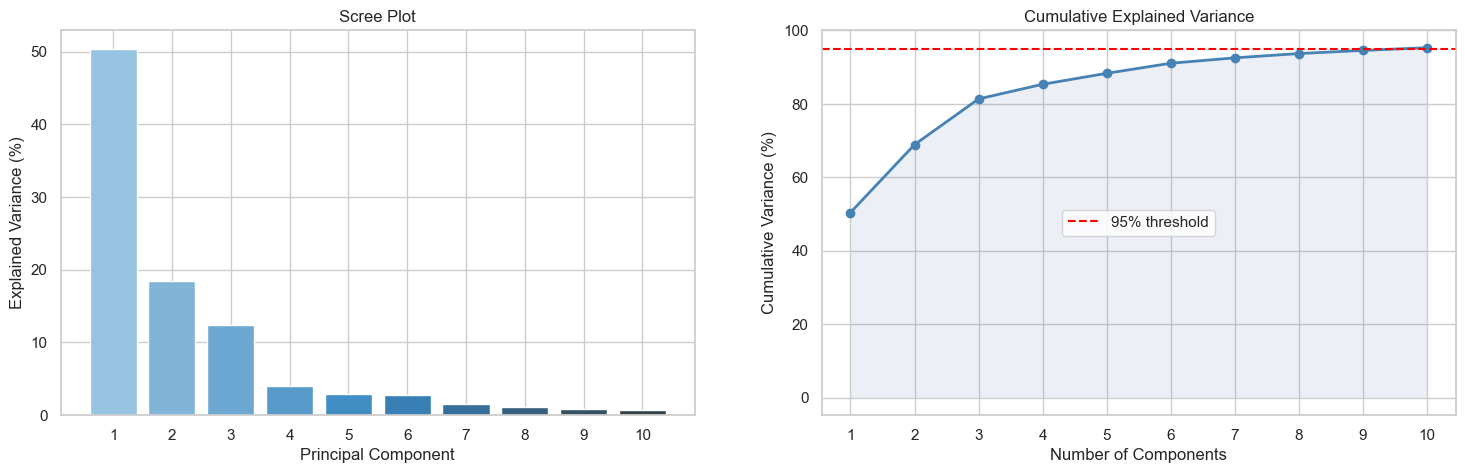

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- Plot 1: Scree plot (individual variance) ---
axes[0].bar(range(1, n_components + 1), explained_variance * 100,
            color=sns.color_palette("Blues_d", n_components))
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot")
axes[0].set_xticks(range(1, n_components + 1))

# --- Plot 2: Cumulative variance ---
axes[1].plot(range(1, n_components + 1), cumulative_variance * 100,
             marker='o', color='steelblue', linewidth=2)
axes[1].axhline(y=95, color='red', linestyle='--', label='95% threshold')
axes[1].fill_between(range(1, n_components + 1), cumulative_variance * 100, alpha=0.1)
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xticks(range(1, n_components + 1))
axes[1].legend()

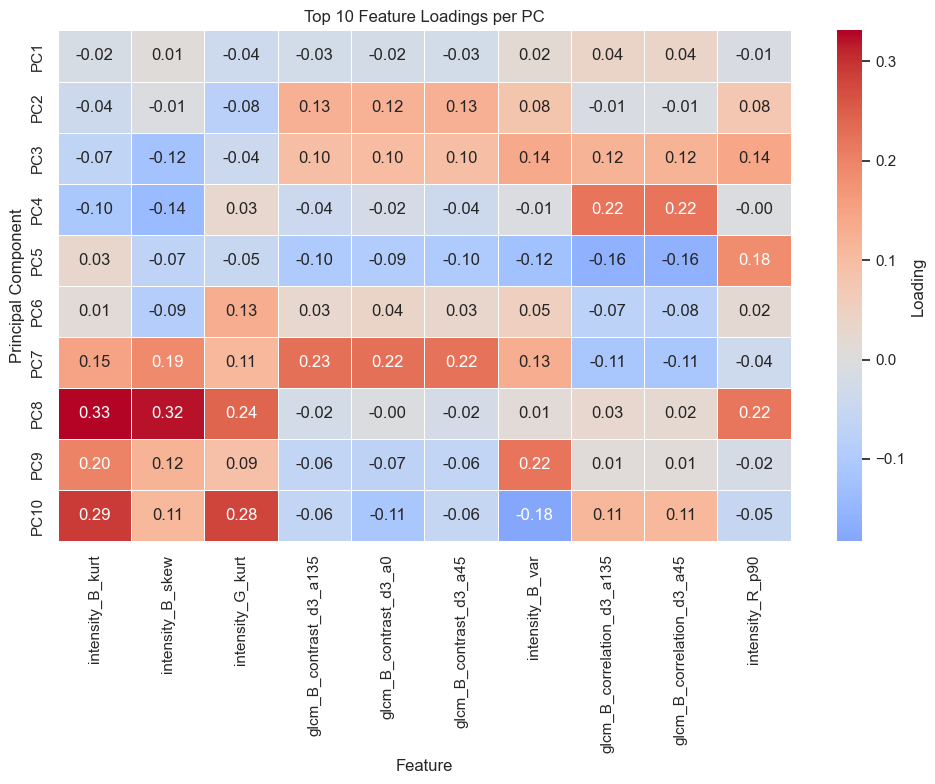

In [ ]:
top_n = 10
top_features = components_df.abs().max(axis=0).nlargest(top_n).index
loading_subset = components_df[top_features]

plt.figure(figsize=(10, 8))

sns.heatmap(
    loading_subset,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Loading"}
)
plt.title(f"Top {top_n} Feature Loadings per PC")
plt.xlabel("Feature")
plt.ylabel("Principal Component")
plt.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## Lower Dimension Visualization: t-SNE

Visualization purpose on overall data points seperation on lower dimensional space to asnwer: "is the data easily seperated?"

In [50]:
X_pca = pca_pipeline.transform(X_features)  # use your already-fitted pipeline

tsne = TSNE(
    n_components=2,
    perplexity=30, # try 5–50, lower = more local structure
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

In [152]:
tsne_df = pd.DataFrame(X_tsne, columns=["TSNE-1", "TSNE-2"])
tsne_df["label"] = class_id_to_name(y.flatten())

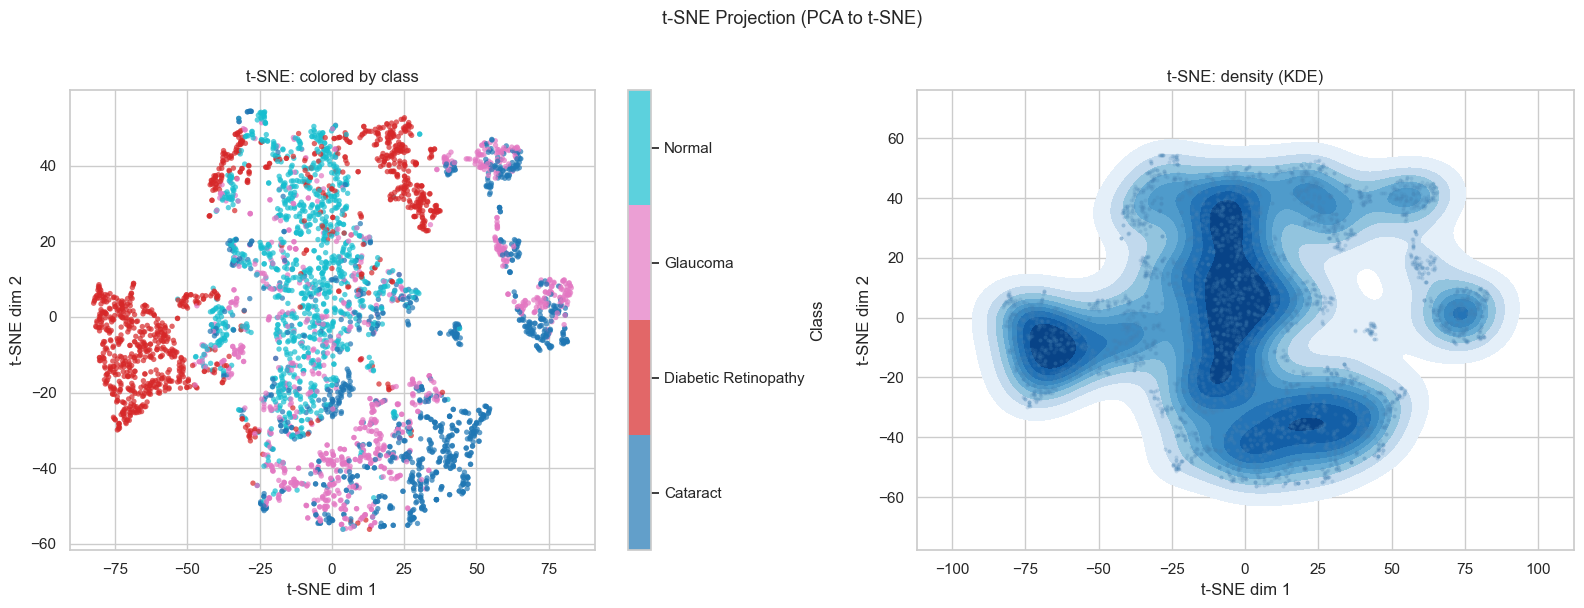

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels = tsne_df["label"].astype("category")
codes = labels.cat.codes
class_names = labels.cat.categories.tolist()
n_classes = len(class_names)

cmap = plt.colormaps["tab10"].resampled(n_classes)

# Plot A: colored by label/class
scatter = axes[0].scatter(
    tsne_df["TSNE-1"], tsne_df["TSNE-2"],
    c=codes, cmap=cmap, vmin=-0.5, vmax=n_classes - 0.5,
    alpha=0.7, s=15, linewidths=0
)
axes[0].set_title("t-SNE: colored by class")
axes[0].set_xlabel("t-SNE dim 1")
axes[0].set_ylabel("t-SNE dim 2")

cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_ticks(range(n_classes))
cbar.set_ticklabels(class_names)
cbar.set_label("Class")

# Plot B: density (KDE), reveals cluster density without needing labels
sns.kdeplot(
    x=tsne_df["TSNE-1"], y=tsne_df["TSNE-2"],
    ax=axes[1], fill=True, cmap="Blues", thresh=0.05, levels=10
)
axes[1].scatter(
    tsne_df["TSNE-1"], tsne_df["TSNE-2"],
    color="steelblue", alpha=0.2, s=8, linewidths=0
)
axes[1].set_title("t-SNE: density (KDE)")
axes[1].set_xlabel("t-SNE dim 1")
axes[1].set_ylabel("t-SNE dim 2")

plt.suptitle("t-SNE Projection (PCA to t-SNE)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("tsne_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Split the Data

Splot the X and y into training and test set, here are the following split:

- 80% training data
- 20% test data

We make sure to set random_state to 42 (any number works) for reproducibility

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
print("Train Set Class Distribution: ")
class_percentage(y_train)
print("\nTest Set Class Distribution: ")
class_percentage(y_test)

Train Set Class Distribution: 
Total samples: 3373

normal: 25.47%  (859 samples)
cataract: 24.61%  (830 samples)
diabetic_retinopathy: 26.03%  (878 samples)
glaucoma: 23.90%  (806 samples)

Test Set Class Distribution: 
Total samples: 844

normal: 25.47%  (215 samples)
cataract: 24.64%  (208 samples)
diabetic_retinopathy: 26.07%  (220 samples)
glaucoma: 23.82%  (201 samples)


## Cross Validation 

To make sure that the performance of our model is not determined by a single split, meaning we will see the true performance of our model by evaluating N splits to produce true metrics

In [58]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Modeling

We will be using at least 3 models to see which performs the best including hyperparamter tuning

### 1. Logistic Regression

In [59]:
logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42, solver='saga'))
])

logreg_param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2'],
}

logreg_grid = GridSearchCV(
    logreg_pipe,
    logreg_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

### 2. Support Vector Machine (SVM)

In [62]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC(probability=True, random_state=42, kernel='rbf'))
])

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001]
}

svm_grid = GridSearchCV(
    svm_pipe,
    svm_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

### 3. Random Forest

In [63]:
rf_pipe = Pipeline([
    ('rf', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'rf__n_estimators': [500, 600, 700],
    'rf__max_depth': [None, 3, 5],
    'rf__min_samples_split': [2, 3],
    'rf__min_samples_leaf': [1, 2],
    'rf__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

## Model Training

In [74]:
logreg_grid.fit(X_train, y_train.ravel())
svm_grid.fit(X_train, y_train.ravel())
rf_grid.fit(X_train, y_train.ravel())

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__max_depth': [None, 3, ...], 'rf__max_features': ['sqrt', 'log2'], 'rf__min_samples_leaf': [1, 2], 'rf__min_samples_split': [2, 3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- 

## Best Estimators & Parameters

In [77]:
best_logreg = logreg_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_rf = rf_grid.best_estimator_

In [78]:
logreg_grid.best_params_, svm_grid.best_params_, rf_grid.best_params_

({'logreg__C': 1, 'logreg__penalty': 'l2'},
 {'svm__C': 100, 'svm__gamma': 0.01},
 {'rf__max_depth': None,
  'rf__max_features': 'sqrt',
  'rf__min_samples_leaf': 1,
  'rf__min_samples_split': 3,
  'rf__n_estimators': 500})

In [79]:
cm_labels = class_mapping.values()

## Model Evaluation

In [90]:
def show_learning_curve(model, name, X, y, cv, ax=None):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring='balanced_accuracy',
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # training curve
    ax.plot(
        train_sizes,
        train_mean,
        'o-',
        color='blue',
        label=f'Training: {train_mean[-1]:.4f}'
    )
    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2,
        color='blue'
    )

    # validation curve
    ax.plot(
        train_sizes,
        test_mean,
        'o-',
        color='green',
        label=f'Validation: {test_mean[-1]:.4f}'
    )
    ax.fill_between(
        train_sizes,
        test_mean - test_std,
        test_mean + test_std,
        alpha=0.2,
        color='green'
    )

    ax.set_title(f'Learning Curve ({name})')
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('Balanced Accuracy')
    ax.grid(True)
    ax.legend()

In [155]:
def show_confusion_matrix(y_true, y_pred, display_labels, ax=None):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        normalize="true"
    )

    annot = np.empty_like(cm).astype(str)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_norm[i, j]:.2f})"

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(
        cm_norm,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=display_labels,
        yticklabels=display_labels,
        linewidths=0.5,
        linecolor="lightgray",
        cbar=True,
        ax=ax
    )

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right"
    )
    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=45
    )
    ax.set_title("Confusion Matrix")

In [103]:
def show_calibration_curve(model, name, X_test, y_test, ax=None, n_bins=10):
    y_proba = model.predict_proba(X_test)
    y_pred = np.argmax(y_proba, axis=1)

    confidence = np.max(y_proba, axis=1)
    correct = (y_pred == y_test).astype(int)

    prob_true, prob_pred = calibration_curve(
        correct,
        confidence,
        n_bins=n_bins,
        strategy="uniform"
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(prob_pred, prob_true, marker="o", label=name)
    ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

    ax.set_title(f"Calibration Curve ({name})")
    ax.set_xlabel("Mean predicted confidence")
    ax.set_ylabel("Fraction of correct predictions")
    ax.grid(True)
    ax.legend()

In [ ]:
def show_multiclass_roc_curve(
    model,
    name,
    X_test,
    y_test,
    class_names,
    ax
):
    y_true = np.asarray(y_test).ravel()

    y_proba = model.predict_proba(X_test)

    n_classes = len(class_names)

    # one-hot encode labels
    y_bin = label_binarize(
        y_true,
        classes=np.arange(n_classes)
    )

    # plot ROC curve for each class
    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            y_bin[:, i],
            y_proba[:, i]
        )

        roc_auc = auc(fpr, tpr)

        ax.plot(
            fpr,
            tpr,
            label=f"{class_names[i]} (AUC = {roc_auc:.3f})"
        )

    # random classifier line
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )
    ax.set_title(f"Multiclass ROC Curve ({name})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True)
    ax.legend(loc="lower right")

### 1. Logistic Regression

In [99]:
y_test.shape

(844, 1)

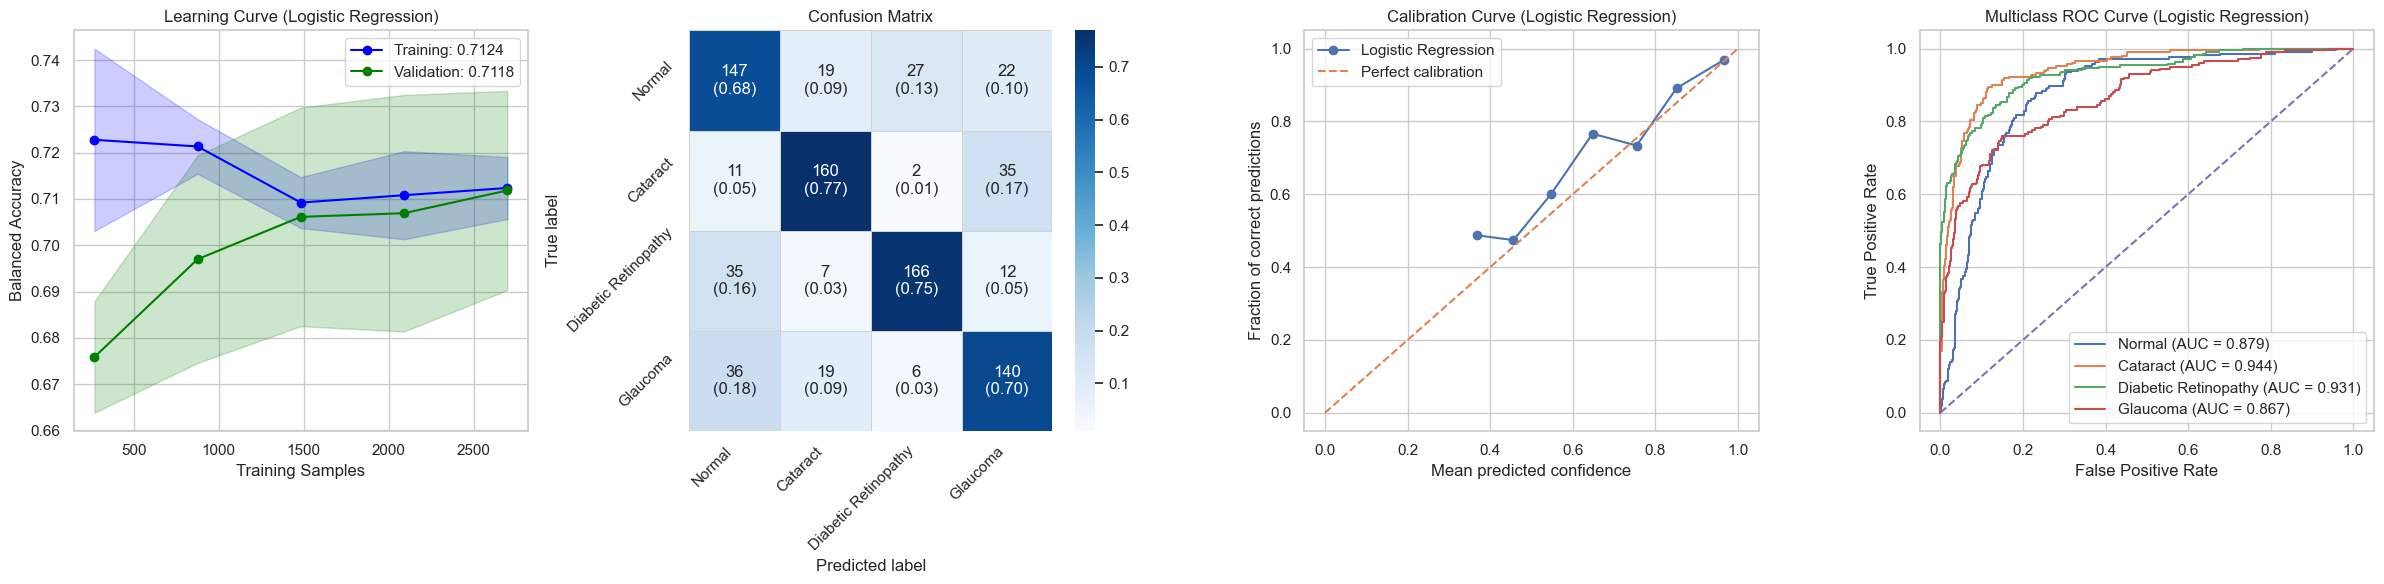

Best CV Accuracy: 0.7263
F1 Score: 0.7271
Recall: 0.7260
Precision: 0.7295


In [156]:
logreg_acc = best_logreg.score(X_test, y_test)

logreg_pred = best_logreg.predict(X_test)

fig, ax = plt.subplots(1, 4, figsize=(24, 6))
show_learning_curve(
    best_logreg,
    "Logistic Regression",
    X_train,
    y_train,
    cv,
    ax=ax[0]
)
show_confusion_matrix(
    y_test,
    logreg_pred,
    display_labels=cm_labels,
    ax=ax[1]
)
show_calibration_curve(best_logreg, "Logistic Regression", X_test, y_test.ravel(), ax=ax[2])
show_multiclass_roc_curve(best_logreg, "Logistic Regression", X_test, y_test.ravel(), list(cm_labels), ax=ax[3])
plt.tight_layout()
plt.show()

logreg_f1 = f1_score(y_test, logreg_pred, average="macro")
logreg_recall = recall_score(y_test, logreg_pred, average="macro")
logreg_precision = precision_score(y_test, logreg_pred, average="macro")

print(f"Best CV Accuracy: {logreg_acc:.4f}")
print(f"F1 Score: {logreg_f1:.4f}")
print(f"Recall: {logreg_recall:.4f}")
print(f"Precision: {logreg_precision:.4f}")

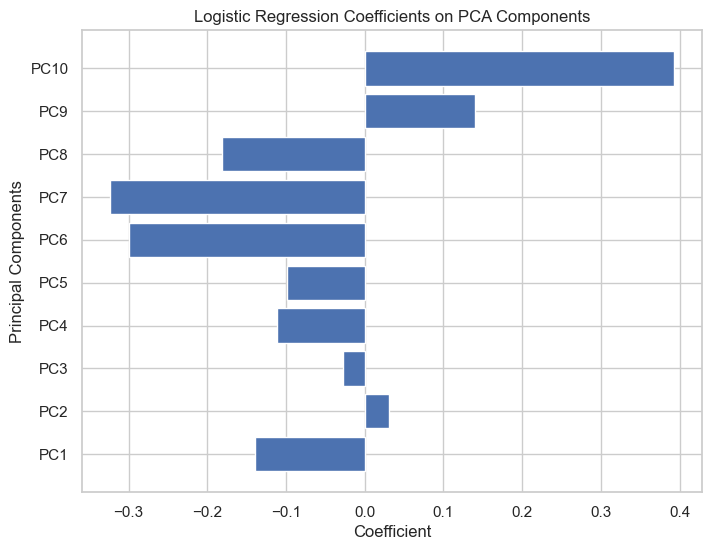

In [123]:
pca = best_logreg.named_steps["pca"]

feature_names = [
    f"PC{i+1}"
    for i in range(pca.n_components_)
]

coef = best_logreg.named_steps["logreg"].coef_[0]

plt.figure(figsize=(8, 6))
plt.barh(feature_names, coef)
plt.xlabel("Coefficient")
plt.ylabel("Principal Components")
plt.title("Logistic Regression Coefficients on PCA Components")
plt.show()

### 2. Support Vector Machine (SVM)

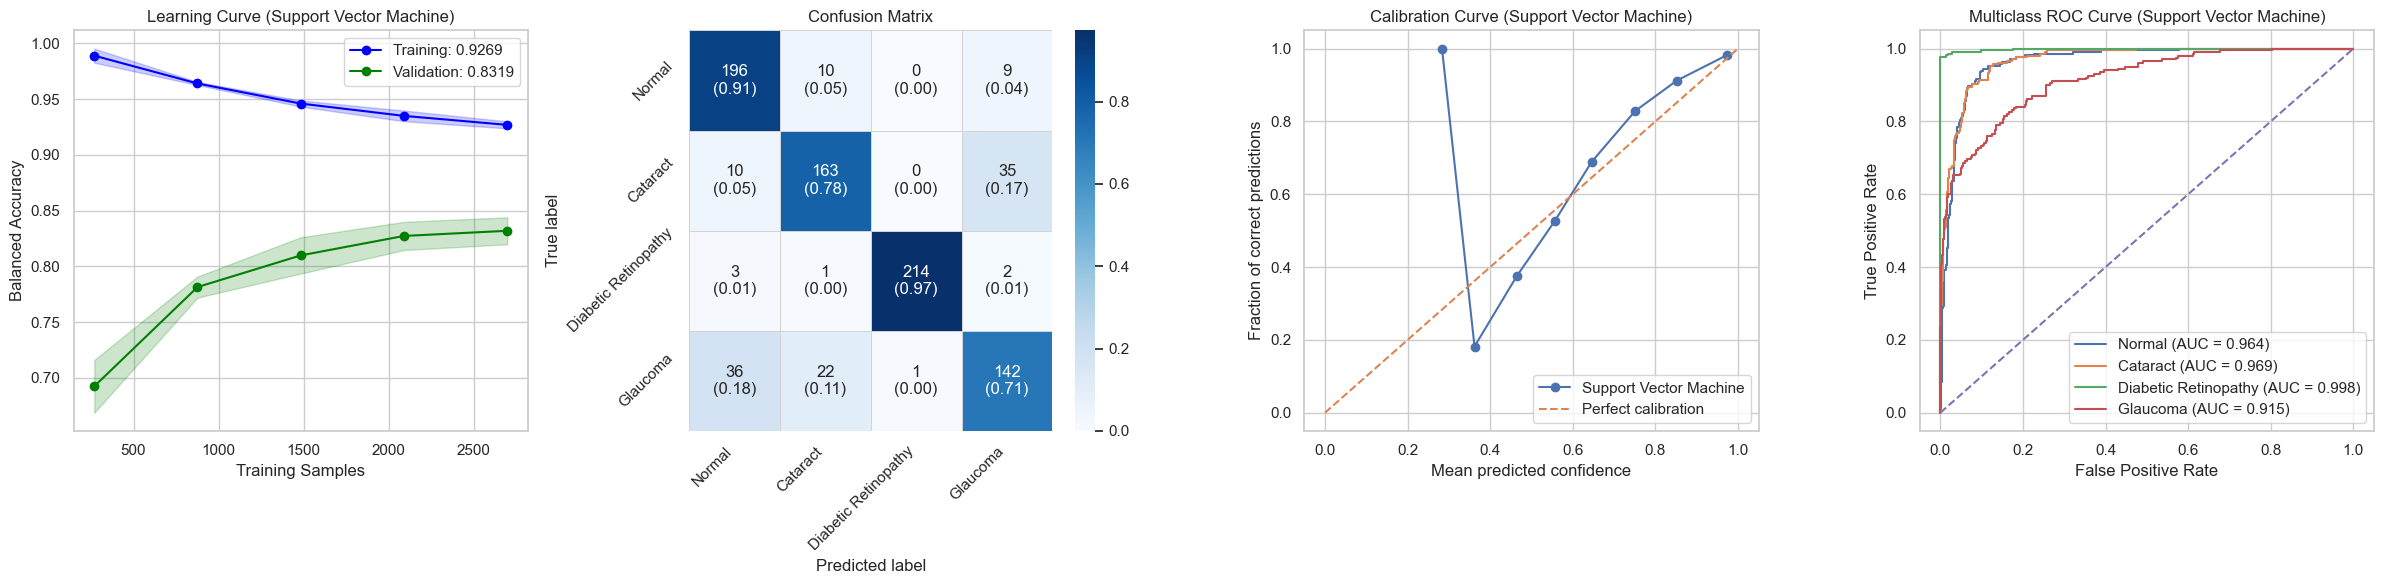

Best CV Accuracy: 0.8472
F1 Score: 0.8433
Recall: 0.8436
Precision: 0.8456


In [157]:
svm_acc = best_svm.score(X_test, y_test)

svm_pred = best_svm.predict(X_test)

fig, ax = plt.subplots(1, 4, figsize=(24, 6))
show_learning_curve(
    best_svm,
    "Support Vector Machine",
    X_train,
    y_train,
    cv,
    ax=ax[0]
)
show_confusion_matrix(
    y_test,
    svm_pred,
    display_labels=cm_labels,
    ax=ax[1]
)
show_calibration_curve(best_svm, "Support Vector Machine", X_test, y_test.ravel(), ax=ax[2])
show_multiclass_roc_curve(best_svm, "Support Vector Machine", X_test, y_test.ravel(), list(cm_labels), ax=ax[3])
plt.tight_layout()
plt.show()

svm_f1 = f1_score(y_test, svm_pred, average="macro")
svm_recall = recall_score(y_test, svm_pred, average="macro")
svm_precision = precision_score(y_test, svm_pred, average="macro")

print(f"Best CV Accuracy: {svm_acc:.4f}")
print(f"F1 Score: {svm_f1:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"Precision: {svm_precision:.4f}")

### 3. Random Forest

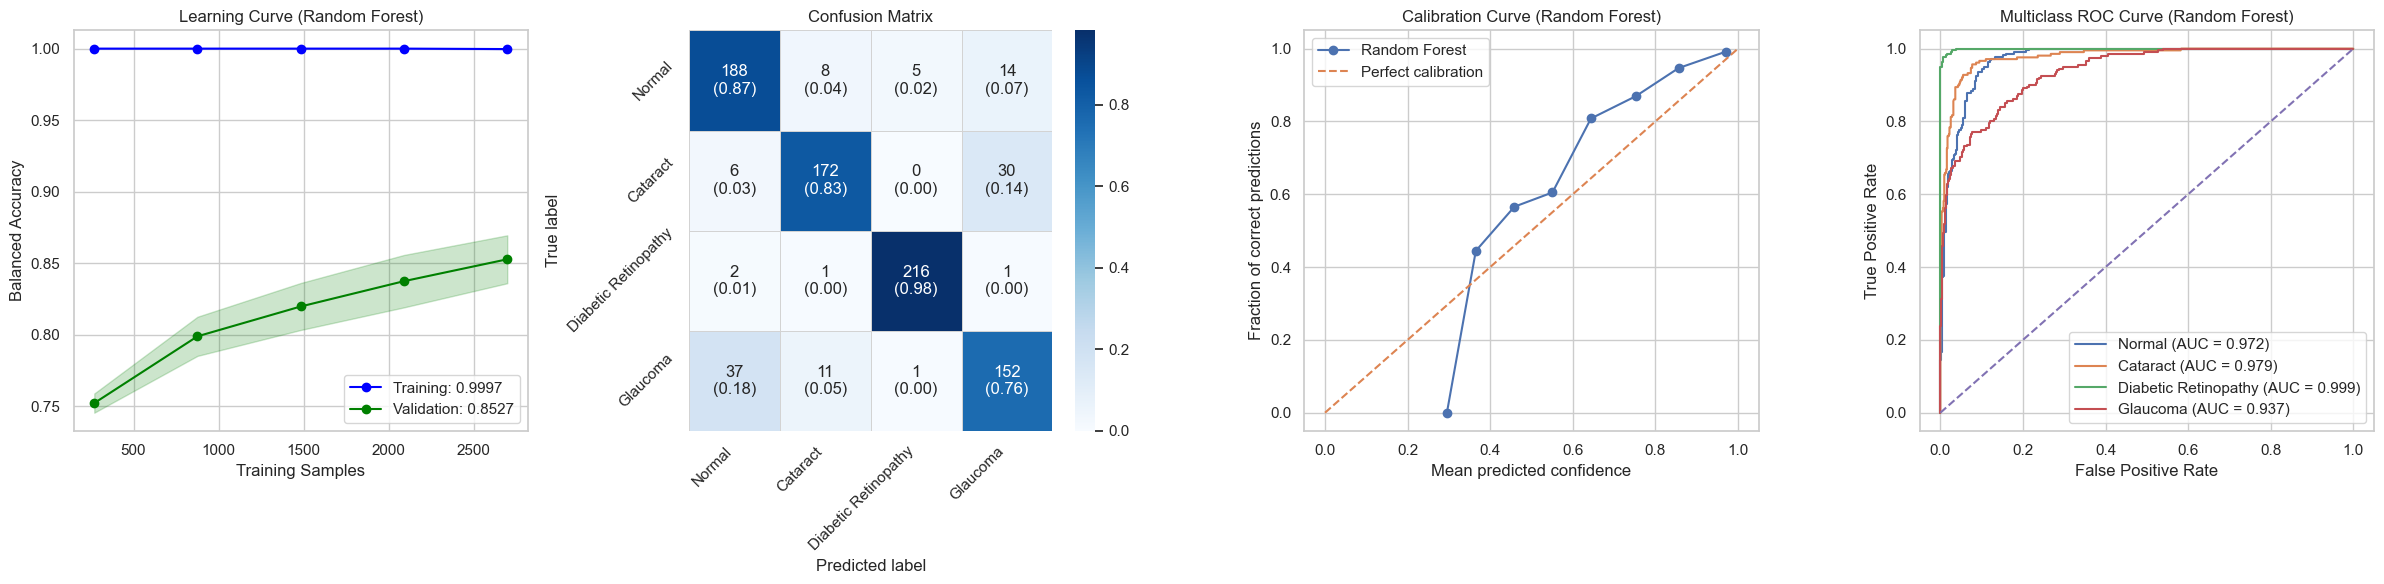

Best CV Accuracy: 0.8626
F1 Score: 0.8601
Recall: 0.8598
Precision: 0.8618


In [158]:
rf_acc = best_rf.score(X_test, y_test)

rf_pred = best_rf.predict(X_test)

fig, ax = plt.subplots(1, 4, figsize=(24, 6))
show_learning_curve(
    best_rf,
    "Random Forest",
    X_train,
    y_train,
    cv,
    ax=ax[0]
)
show_confusion_matrix(
    y_test,
    rf_pred,
    display_labels=cm_labels,
    ax=ax[1]
)
show_calibration_curve(best_rf, "Random Forest", X_test, y_test.ravel(), ax=ax[2])
show_multiclass_roc_curve(best_rf, "Random Forest", X_test, y_test.ravel(), list(cm_labels), ax=ax[3])
plt.tight_layout()
plt.show()

rf_f1 = f1_score(y_test, rf_pred, average="macro")
rf_recall = recall_score(y_test, rf_pred, average="macro")
rf_precision = precision_score(y_test, rf_pred, average="macro")

print(f"Best CV Accuracy: {rf_acc:.4f}")
print(f"F1 Score: {rf_f1:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"Precision: {rf_precision:.4f}")

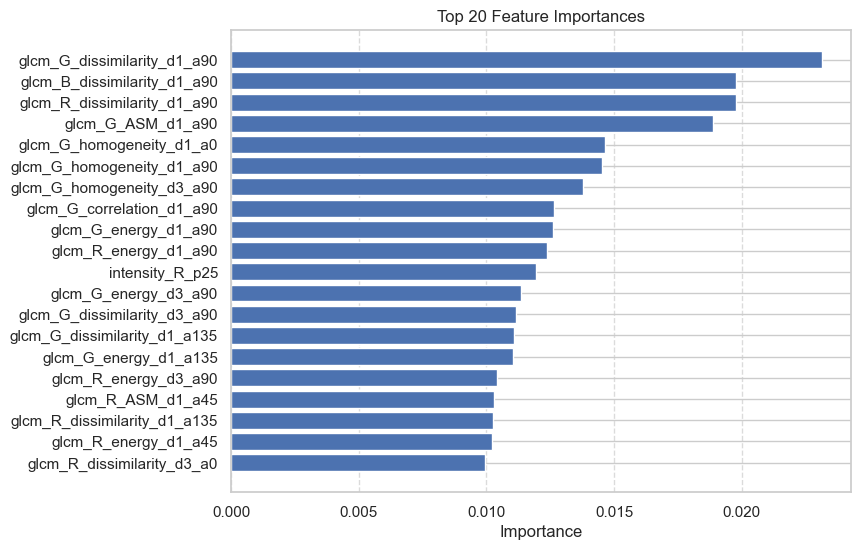

In [117]:
# get feature importances
importances = best_rf.named_steps['rf'].feature_importances_
feature_names = get_intensity_stats_names() + get_glcm_feature_names()

# sort importances descending
indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = [feature_names[i] for i in indices]

TOP_K = 20

top_features = sorted_features[:TOP_K]
top_importances = sorted_importances[:TOP_K]

plt.figure(figsize=(8, 6))
plt.barh(top_features, top_importances)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title(f"Top {TOP_K} Feature Importances")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [118]:
report = classification_report(y_test, rf_pred, output_dict=True)

df_report = pd.DataFrame(report).transpose()
df_report.head(4 + 4)

,precision,recall,f1-score,support
0,0.806867,0.874419,0.839286,215.000000
1,0.895833,0.826923,0.860000,208.000000
2,0.972973,0.981818,0.977376,220.000000
3,0.771574,0.756219,0.763819,201.000000
accuracy,0.862559,0.862559,0.862559,0.862559
macro avg,0.861812,0.859845,0.860120,844.000000
weighted avg,0.863685,0.862559,0.862413,844.000000


## Permutation Importance 

Permutation importance measures how much the model performance decreases when a feature is randomly shuffled

If shuffling a feature causes a large drop in performance, the feature is considered important because the model relies heavily on it

In [126]:
def plot_permutation_importance(
    model,
    model_name,
    X_test,
    y_test,
    feature_names,
    ax,
    scoring="balanced_accuracy",
    n_repeats=10,
    top_n=15,
    random_state=42
):
    y_true = np.asarray(y_test).ravel()

    result = permutation_importance(
        model,
        X_test,
        y_true,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    importance_mean = result.importances_mean
    importance_std = result.importances_std

    indices = np.argsort(importance_mean)[-top_n:]

    ax.barh(
        np.array(feature_names)[indices],
        importance_mean[indices],
        xerr=importance_std[indices],
        alpha=0.8
    )

    ax.set_title(f"{model_name}\nPermutation Importance")
    ax.set_xlabel(f"Decrease in {scoring}")
    ax.grid(axis="x", alpha=0.3)

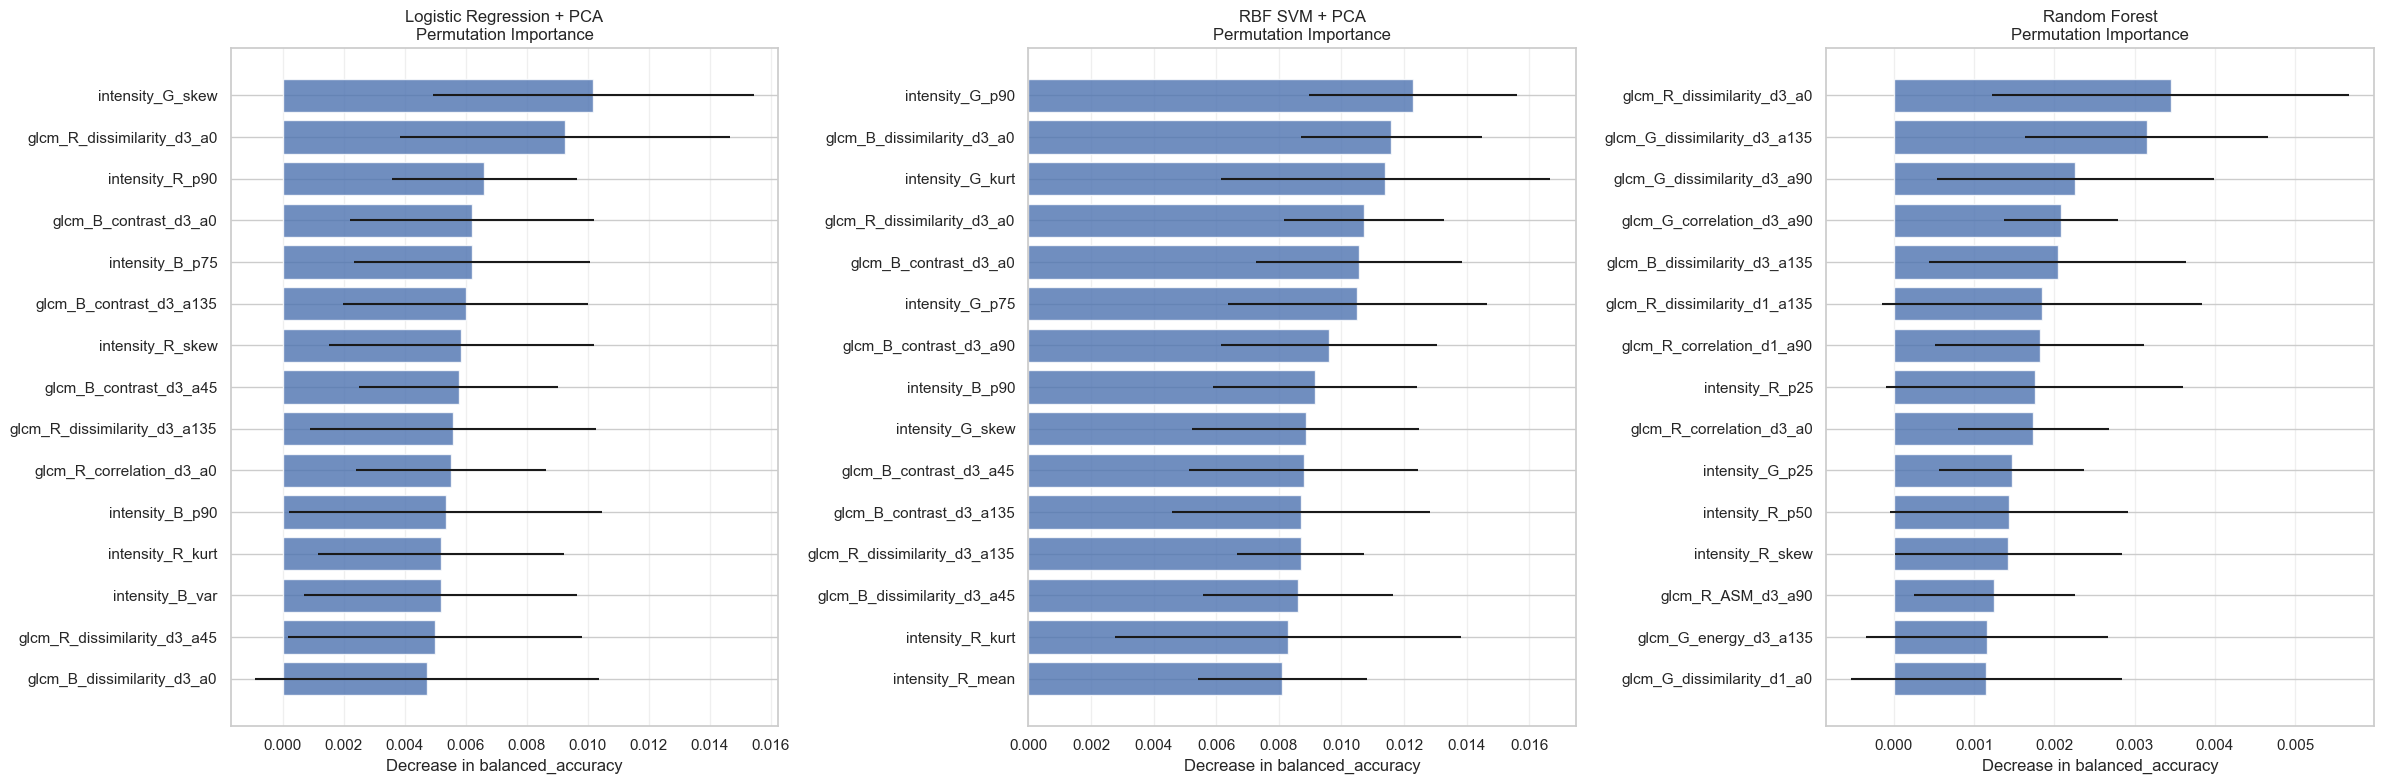

In [127]:
feature_names = X_features.columns

fig, ax = plt.subplots(1, 3, figsize=(24, 8))

plot_permutation_importance(
    best_logreg,
    "Logistic Regression + PCA",
    X_test,
    y_test,
    feature_names,
    ax=ax[0],
    top_n=15
)
plot_permutation_importance(
    best_svm,
    "RBF SVM + PCA",
    X_test,
    y_test,
    feature_names,
    ax=ax[1],
    top_n=15
)
plot_permutation_importance(
    best_rf,
    "Random Forest",
    X_test,
    y_test,
    feature_names,
    ax=ax[2],
    top_n=15
)
plt.tight_layout()
plt.show()

## Save models to disk

In [159]:
pickle.dump(best_logreg, open("best_logreg.pkl", "wb"))
pickle.dump(best_svm, open("best_svm.pkl", "wb"))
pickle.dump(best_rf, open("best_rf.pkl", "wb"))

In [161]:
print("pipeline finished")

pipeline finished
